In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import climattr as eea

plt.rcParams.update({'font.size': 14})

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_61127/3195340363.py:4: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  pop = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_61127/3195340363.py:24: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  obs_temp = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_61127/3195340363.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby

North
-53.717499994659626 -52.984805967671704 -52.31393744246642
-53.18726781376262 -52.98885393903243 -52.810781373092105
Northeast
-24.212461036717556 -23.83051113132018 -23.468136363799804
-23.882397504283436 -23.833473891198587 -23.79085640057095
Middle-West
32.34282961827796 33.211386220177225 34.078298302284914
33.4593725462324 33.21410052612643 33.01671673176069
Southeast
37.123177036709826 38.27014974087094 39.35137517153385
38.169568544693895 38.25945786207029 38.37555459092668
South
40.254510078754265 41.65443696501411 43.08246934216898
41.72941434705631 41.666328488460415 41.61196352940662


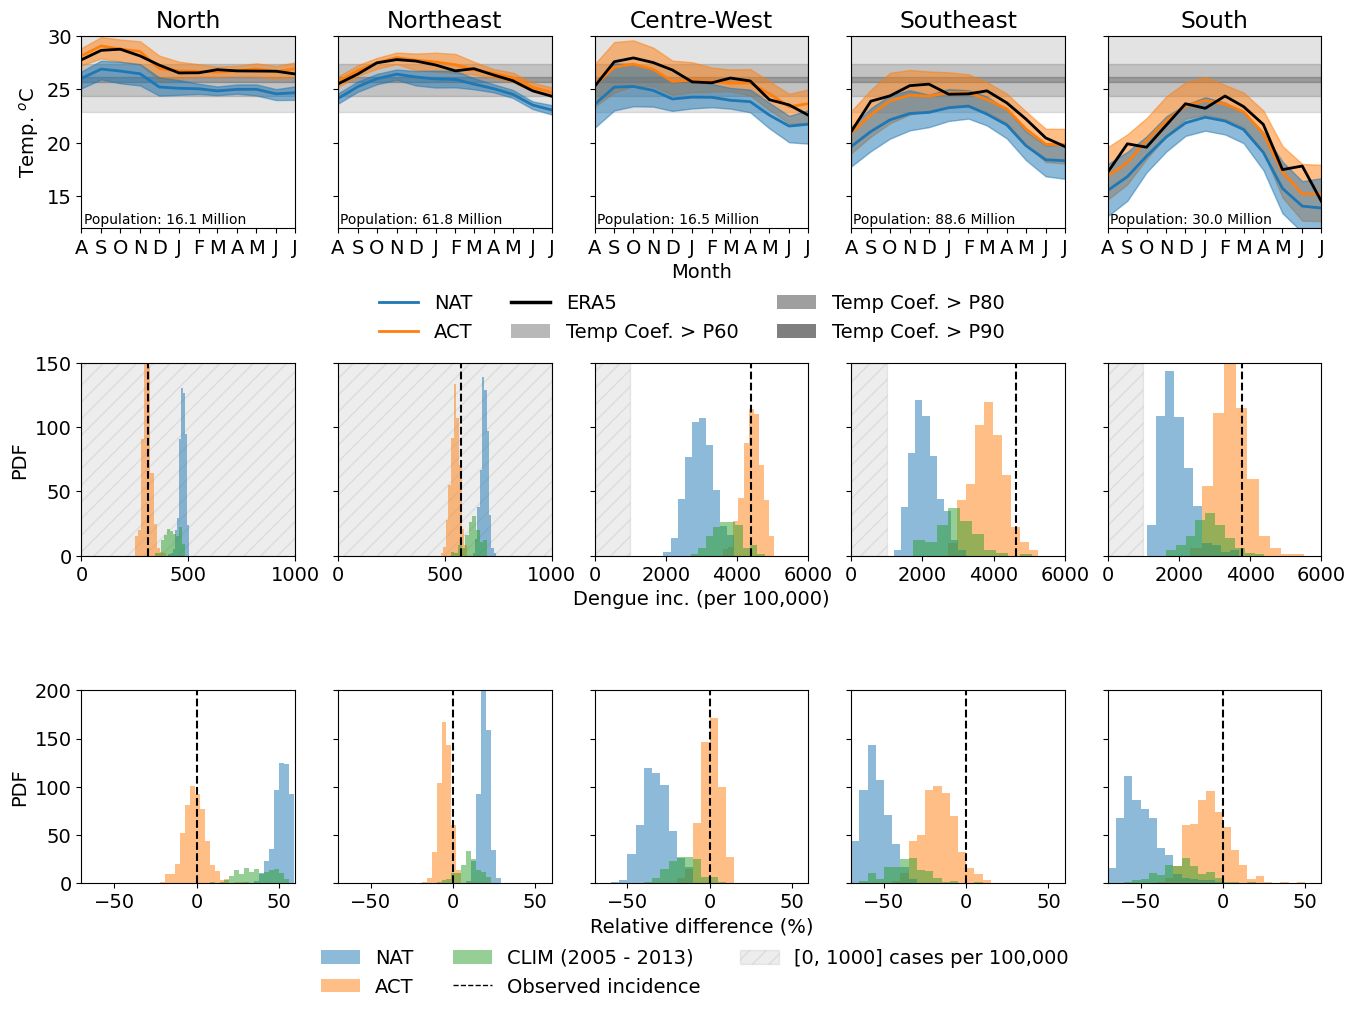

In [3]:
fig, axarr = plt.subplots(3, 5, figsize=(16, 11))
plt.subplots_adjust(wspace=0.2, hspace=0.7)

pop = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
pop = pop[pop['date_first_symptoms'] == '2023-08-01']
pop = pop.groupby('region').agg({'population': 'sum'})
pop['population'] = pop['population'] / 1e6

# Temperature plots
ext = pd.read_csv('data/ext_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)
nat = pd.read_csv('data/nat_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)

obs = pd.read_csv('data/model_input_brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
obs = obs.groupby(['region', 'date_first_symptoms']).mean(numeric_only=True).reset_index()

ext['time'] = ext['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))
nat['time'] = nat['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))

regions = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']

ext_temp = pd.read_csv('data/ext_temp.csv')
nat_temp = pd.read_csv('data/nat_temp.csv')

obs_temp = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
obs_temp = obs_temp[(obs_temp['date_first_symptoms'] >= '2023-08-01') & (obs_temp['date_first_symptoms'] <= '2024-07-31')]

obs_temp = obs_temp.groupby('region').apply(lambda x: (x['mean_2m_air_temp_degree1'] * x['population']).sum() / x['population'].sum())
obs_temp = obs_temp.reset_index().rename(columns={0: 'mean_2m_air_temp_degree1'})


# First row - Temperature
for i, region in enumerate(regions):
    ext_subset = ext[ext['region'] == region]
    nat_subset = nat[nat['region'] == region]

    ext_quantiles = ext_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()
    nat_quantiles = nat_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()

    ax = axarr[0, i]

    spans = [
        [0.6, 22.9, 30, '#737373'],
        [0.8, 24.4, 27.4, '#404040'],
        [0.9, 25.7, 26.2, '#000000']
    ]

    for span in spans:
        ax.axhspan(span[1], span[2], color=span[3], alpha=0.2)

    ax.fill_between(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'],
        ext_quantiles[ext_quantiles['level_1'] == 0.025]['tas'],
        ext_quantiles[ext_quantiles['level_1'] == 0.975]['tas'],
        color='C1', alpha=0.5
    )
    ax.plot(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'], 
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['tas'],
        color='C1', lw=2
    )

    ax.fill_between(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'],
        nat_quantiles[nat_quantiles['level_1'] == 0.025]['tas'],
        nat_quantiles[nat_quantiles['level_1'] == 0.975]['tas'],
        color='C0', alpha=0.5
    )
    ax.plot(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'], 
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['tas'],
        color='C0', lw=2
    )

    ax.plot(
        obs[obs['region'] == region]['date_first_symptoms'],
        obs[obs['region'] == region]['mean_2m_air_temp_degree1'],
        color='k', lw=2
    )

    ax.set_xlim(pd.to_datetime('2023-08-01'), pd.to_datetime('2024-07-31'))
    ax.set_xticks(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='4MS')
    )
    ax.set_xticklabels(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='4MS').strftime('%m/%y')
    )

    ax.set_title(region) if region != 'Middle-West' else ax.set_title('Centre-West')
    ax.set_xlim(pd.to_datetime('2023-08-01'), pd.to_datetime('2024-07-01'))
    ax.set_xticks(pd.date_range('2023-08-01', '2024-07-31', freq='MS'))
    ax.set_xticklabels(list('ASONDJFMAMJJ'))
    if i == 2:
        ax.set_xlabel('Month')
    ax.set_ylim([12, 30])
    ax.text(0.01, 0.01, f"Population: {pop.loc[region, 'population']:.1f} Million", transform=ax.transAxes, fontsize=10, verticalalignment='bottom')


# Add dengue incidence plots
ext = pd.read_csv('data/all_brazil-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])
nat = pd.read_csv('data/nat_brazil-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])
act = pd.read_csv('data/dengue_regional_aggregation.csv', parse_dates=['date_first_symptoms'])
hst = pd.read_csv('data/hist_brazil-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])

hst['year'] = hst['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

ext = ext[ext['region'].isin(regions)]
nat = nat[nat['region'].isin(regions)]
hst = hst[hst['region'].isin(regions) & (hst['year'] < 2014)]
act = act[act['region'].isin(regions) & (act['date_first_symptoms'] >= '2023-08-01') & (act['date_first_symptoms'] <= '2024-07-01')]

ext['predicted_cases'] = ext['predicted_incidence'] * ext['total_population'] / 1e5
nat['predicted_cases'] = nat['predicted_incidence'] * nat['total_population'] / 1e5
act['actual_cases'] = act['actual_regional_incidence'] * act['total_population'] / 1e5
hst['predicted_cases'] = hst['predicted_incidence'] * hst['total_population'] / 1e5

ext = ext.groupby(['region', 'file_number']).agg({'predicted_cases': 'sum', 'total_population': 'mean'}).reset_index()
nat = nat.groupby(['region', 'file_number']).agg({'predicted_cases': 'sum', 'total_population': 'mean'}).reset_index()
act = act.groupby(['region']).agg({'total_population': 'mean', 'actual_cases': 'sum'}).reset_index()
hst = hst.groupby(['region', 'year', 'file_number']).agg({'predicted_cases': 'sum', 'total_population': 'mean'}).reset_index()

ext['predicted_incidence'] = 1e5 * ext['predicted_cases'] / ext['total_population']
nat['predicted_incidence'] = 1e5 * nat['predicted_cases'] / nat['total_population']
act['actual_incidence'] = 1e5 * act['actual_cases'] / act['total_population']
hst['predicted_incidence'] = 1e5 * hst['predicted_cases'] / hst['total_population']

nat[nat['region'] == 'South'] = nat[(nat['region'] == 'South') & (nat['predicted_incidence'] <= 4000)]


# Third row - Dengue incidence histogram (normalized)
for i, (ax, region) in enumerate(zip(axarr[2], regions)):    
    act_region = act[act['region'] == region]['actual_incidence'].values[0]

    bins1 = np.arange(-70, 60, 3)
    bins2 = np.arange(-70, 60, 5)
    if region in ['North', 'Northeast']:
        bins = bins1
    else:
        bins = bins2

    ax.hist(100 * (ext[ext['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C1', alpha=0.5, bins=bins)
    ax.hist(100 * (nat[nat['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C0', alpha=0.5, bins=bins)
    ax.hist(100 * (hst[hst['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C2', alpha=0.5, bins=bins)

    np.random.seed(42)
    bootstrap_ext = np.random.choice(ext[ext['region'] == region]['predicted_incidence'], size=(1000, 525), replace=True).mean(axis=1)
    bootstrap_nat = np.random.choice(nat[nat['region'] == region]['predicted_incidence'], size=(1000, 525), replace=True).mean(axis=1)

    diff = 100 * (bootstrap_ext - bootstrap_nat) / act_region

    print(region)
    print(np.percentile(diff, 2.5), np.percentile(diff, 50), np.percentile(diff, 97.5))
    print(
        100 * (np.percentile(bootstrap_ext, 2.5) / act_region - np.percentile(bootstrap_nat, 2.5) / act_region),
        100 * (np.percentile(bootstrap_ext, 50) / act_region - np.percentile(bootstrap_nat, 50) / act_region),
        100 * (np.percentile(bootstrap_ext, 97.5) / act_region - np.percentile(bootstrap_nat, 97.5) / act_region)
    )

    ax.axvline(0, color='k', ls='--')
    if i == 2:
        ax.set_xlabel('Relative difference (%)')
    ax.set_ylim([0, 200])
    ax.set_xlim([-70, 60])

# Second row - Dengue incidence histogram (absolute)
for i, (ax, region) in enumerate(zip(axarr[1], regions)):    
    act_region = act[act['region'] == region]['actual_incidence'].values[0]

    if region in ['North', 'Northeast']:
        ax.set_xlim([0, 1000])
    else:
        ax.set_xlim([0, 6000])

    ax.axvspan(0, 1000, color='k', alpha=0.07, hatch='//')

    bins1 = np.arange(0, 6000, 5)
    bins2 = np.arange(0, 6000, 10)
    
    if region in ['North', 'Northeast']:
        bins = bins1
    else:
        bins = bins2

    ax.hist(ext[ext['region'] == region]['predicted_incidence'], color='C1', alpha=0.5)
    ax.hist(nat[nat['region'] == region]['predicted_incidence'], color='C0', alpha=0.5)
    ax.hist(hst[hst['region'] == region]['predicted_incidence'], color='C2', alpha=0.5)

    ax.axvline(act_region, color='k', ls='--')
    if i == 2:
        ax.set_xlabel('Dengue inc. (per 100,000)')
    ax.set_ylim([0, 150])
    
axarr[0, 0].set_ylabel(r'Temp. $^o$C')
axarr[1, 0].set_ylabel('PDF')
axarr[2, 0].set_ylabel('PDF')

for i in range(1,5):
    axarr[0, i].set_yticklabels([])
    axarr[1, i].set_yticklabels([])
    axarr[2, i].set_yticklabels([])

legend_elements1 = []
legend_elements2 = []

legend_elements1.append(Line2D([0], [0], color='C0', lw=2, label='NAT'))
legend_elements1.append(Line2D([0], [0], color='C1', lw=2, label='ACT'))
legend_elements1.append(Line2D([0], [0], color='k', lw=2.5, label='ERA5'))
legend_elements1.append(Patch(facecolor='#737373', alpha=0.5, label='Temp Coef. > P60'))
legend_elements1.append(Patch(facecolor='#404040', alpha=0.5, label='Temp Coef. > P80'))
legend_elements1.append(Patch(facecolor='#000000', alpha=0.5, label='Temp Coef. > P90'))

legend_elements2.append(Patch(facecolor='C0', alpha=0.5, label='NAT'))
legend_elements2.append(Patch(facecolor='C1', alpha=0.5, label='ACT'))
legend_elements2.append(Patch(facecolor='C2', alpha=0.5, label='CLIM (2005 - 2013)'))
legend_elements2.append(Line2D([0], [0], color='k', ls='--', lw=1, label='Observed incidence'))
legend_elements2.append(Patch(color='k', hatch='//', alpha=0.07, label='[0, 1000] cases per 100,000'))

# Place legend on the figure level or first axis
axarr[0, 2].legend(handles=legend_elements1, frameon=False, ncol=3, bbox_to_anchor=(2.0, -0.25))
axarr[2, 2].legend(handles=legend_elements2, frameon=False, ncol=3, bbox_to_anchor=(2.3, -0.25))

plt.savefig('img/dengue_temperature_analysis.pdf', dpi=300, bbox_inches='tight')

In [ ]:
models = [
  'Climate(lag 1-5)',
  'Climate(lag 1-5) + Year|region',
  'Climate(lag 1-5) + Month|region',
  'Year + Month + P(Climate)',
  'Climate(lag 1) + Year|region + Month|region',
  'Climate(lag 1-3) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region + Socio',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases',
  'Climate(lag 1-5) + Year|region + Month|region + SeroRepla',
  'Climate(lag 1-5) + Year|region + Month|region + Immunity',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity',
  'Climate(lag 1-5) + Socio',
  'Climate(lag 1-5) + PriorCases',
  'Climate(lag 1-5) + SeroRepla',
  'Climate(lag 1-5) + Immunity',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity'
]

act_all = []
nat_all = []

for model in models:
    print('-' * 60)
    print(f'Model: {model}')
    
    act = pd.read_csv(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue/sensitivity-act/predictions_regional_{model}.csv', parse_dates=['date_first_symptoms'])
    nat = pd.read_csv(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue/sensitivity-nat/predictions_regional_{model}.csv', parse_dates=['date_first_symptoms'])
    
    regions = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']
    
    act = act[act['region'].isin(regions)]
    nat = nat[nat['region'].isin(regions)]
    
    act = act.groupby([
        'model_type', 'region', 'bootstrap_iteration', 'ensemble_member'
    ]).apply(lambda x: pd.Series({
        'predicted_cases': (x['predicted_incidence'] * x['total_population'] / 1e5).sum(),
        'actual_cases': (x['actual_incidence'] * x['total_population'] / 1e5).sum(),
    }), include_groups=False).reset_index()
    
    nat = nat.groupby([
        'model_type', 'region', 'bootstrap_iteration', 'ensemble_member'
    ]).apply(lambda x: pd.Series({
        'predicted_cases': (x['predicted_incidence'] * x['total_population'] / 1e5).sum(),
        'actual_cases': (x['actual_incidence'] * x['total_population'] / 1e5).sum(),
    }), include_groups=False).reset_index()
    
    act = act.groupby(['model_type', 'region', 'bootstrap_iteration']).mean().reset_index()
    nat = nat.groupby(['model_type', 'region', 'bootstrap_iteration']).mean().reset_index()

    act_all.append(act)
    nat_all.append(nat)

act = pd.concat(act_all)
nat = pd.concat(nat_all)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM) (selected)'
}

model_order = {
    "Climate(lag 1-5)": 1,
    "Climate(lag 1-5) + Year|region": 2,
    "Climate(lag 1-5) + Month|region": 3,
    "Climate(lag 1-5) + Socio": 4,
    "Climate(lag 1-5) + SeroRepla": 5,
    "Climate(lag 1-5) + PriorCases": 6,
    "Climate(lag 1-5) + Immunity": 7,
    "Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity": 8,
    "Year + Month + P(Climate)": 9,
    "Climate(lag 1) + Year|region + Month|region": 10,
    "Climate(lag 1-3) + Year|region + Month|region": 11,
    "Climate(lag 1-5) + Year|region + Month|region": 12,
    "Climate(lag 1-5) + Year|region + Month|region + Socio": 13,
    "Climate(lag 1-5) + Year|region + Month|region + PriorCases": 14,
    "Climate(lag 1-5) + Year|region + Month|region + SeroRepla": 15,
    "Climate(lag 1-5) + Year|region + Month|region + Immunity": 16,
    "Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity": 17
}

palette = {
    "C15": "#d4b9da",
    "C15-Yr": "#c994c7",
    "C15-Mr": "#df65b0",
    "C15-c(S)": "#e7298a",
    "C15-c(SR)": "#ce1256",
    "C15-c(PC)": "#980043",
    "C15-c(IM)": "#7a0177",
    "C15-c(PC,SR,S,IM)": "#49006a",
    "Y-M-P(C)": "#e5f5e0",
    "C1-Yr-Mr": "#c7e9c0",
    "C13-Yr-Mr": "#a1d99b",
    "C15-Yr-Mr": "#74c476",
    "C15-Yr-Mr-c(S)": "#41ab5d",
    "C15-Yr-Mr-c(PC)": "#238b45",
    "C15-Yr-Mr-c(SR)": "#006d2c",
    "C15-Yr-Mr-c(IM)": "#00441b",
    "C15-Yr-Mr-c(PC,SR,S,IM) (selected)": "#FF6B00",
}

plt.rcParams.update({'font.size': 14})

diff = act.set_index(
    ['model_type', 'region', 'bootstrap_iteration']
)[['predicted_cases', 'actual_cases']].rename(
    columns={'predicted_cases': 'act', 'actual_cases': 'fitted'}
).join(
    nat.set_index(
        ['model_type', 'region', 'bootstrap_iteration']
    )[['predicted_cases']].rename(
        columns={'predicted_cases': 'nat'}
    )
).reset_index()

diff['diff'] = 100 * (diff['act'] - diff['nat']) / diff['fitted']
diff = diff[(diff['diff'] > -200) & (diff['diff'] < 200)]
diff = diff.reset_index()
diff['model_order'] = diff['model_type'].map(model_order)
diff['model_id'] = diff['model_type'].map(model_ids)
diff = diff.sort_values('model_order')
diff['region'] = diff['region'].replace({'Middle-West': 'Centre-West'})

region_order = ['North', 'Northeast', 'Centre-West', 'Southeast', 'South']

SELECTED = 'C15-Yr-Mr-c(PC,SR,S,IM) (selected)'

# Split into base models and selected model
palette_base = {k: v for k, v in palette.items() if k != SELECTED}
diff_base     = diff[diff['model_id'] != SELECTED]
diff_selected = diff[diff['model_id'] == SELECTED]

fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)

# ── 1. Plot all base models ──────────────────────────────────────────────────
sns.boxplot(
    y='diff',
    x='region',
    hue='model_id',
    data=diff_base,
    ax=ax,
    gap=.2,
    order=region_order,
    hue_order=list(palette_base.keys()),
    palette=palette_base,
    showfliers=False,
)

# ── 2. Plot selected model on top, shifted slightly to the right ─────────────
# dodge=True positions it as an extra hue; we use native_scale + a small
# manual transform via the dodge width calculation instead.
# Easiest: use dodge=True with all hues but hide the others — but that's messy.
# Cleanest: compute x positions manually and use ax.boxplot directly.

n_regions   = len(region_order)
n_base      = len(palette_base)       # 16
total_hues  = len(palette)            # 17
group_width = 0.8                     # seaborn default
box_width   = group_width / total_hues * (1 - 0.2)  # gap=0.2
step        = group_width / total_hues

for r_idx, region in enumerate(region_order):
    region_data = diff_selected[diff_selected['region'] == region]['diff'].dropna()
    if region_data.empty:
        continue

    # x centre of this region group is r_idx (seaborn places groups at 0,1,2,...)
    # position of last hue slot + small extra offset for visual separation
    x_pos = r_idx - group_width / 2 + step * (total_hues - 0.5) + 0.1

    bp = ax.boxplot(
        region_data,
        positions=[x_pos],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        boxprops=dict(facecolor="#FF6B00", color="k"),
        medianprops=dict(color="k", linewidth=1.5),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
    )

    ax.axvspan(x_pos - 0.05, x_pos + 0.05, alpha=0.2, color='grey')

# ── Legend ───────────────────────────────────────────────────────────────────
# Rebuild full legend manually so selected model appears with correct colour
handles, labels = ax.get_legend_handles_labels()
selected_patch = mpatches.Patch(facecolor="#FF6B00", label=SELECTED, edgecolor='k')
handles.append(selected_patch)
labels.append(SELECTED)

ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.20),
    frameon=False,
    fontsize=10,
    ncols=5,
)

ax.set_ylim([-100, 100])
ax.set_ylabel("Normalized Attribution Signal\n(ACT - NAT) (%)")
ax.set_xlabel("Region")
ax.axhline(0, color='k', ls='--')

plt.savefig('figure3_attribution-signal.pdf', dpi=300, bbox_inches='tight')